# Task
Analyze the `S05-hw-dataset.csv` dataset, preprocess it, and build a logistic regression model for classification. Compare its performance (accuracy, ROC-AUC) against a DummyClassifier baseline model, tune hyperparameters using GridSearchCV, plot the ROC curve, and provide a report summarizing the findings. Ensure proper repository structure is created and figures are saved.

## Настройка структуры репозитория и загрузка данных

### Subtask:
Создание необходимых папок (homeworks/, HW05/, figures/, artifacts/) и размещение файла S05-hw-dataset.csv в homeworks/HW05/.


**Reasoning**:
First, I'll create the necessary directories, then move the specified file into the target directory.



In [ ]:
import os
import shutil

# Define directory paths
base_dir = 'homeworks'
hw05_dir = os.path.join(base_dir, 'HW05')
figures_dir = os.path.join(hw05_dir, 'figures')
artifacts_dir = os.path.join(hw05_dir, 'artifacts')

# Create directories if they don't exist
os.makedirs(base_dir, exist_ok=True)
os.makedirs(hw05_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(artifacts_dir, exist_ok=True)

print(f"Directories created: {base_dir}, {hw05_dir}, {figures_dir}, {artifacts_dir}")

# Define source and destination paths for the file
source_file = 'S05-hw-dataset.csv'
destination_file = os.path.join(hw05_dir, 'S05-hw-dataset.csv')

# Move the file
shutil.move(source_file, destination_file)

print(f"Moved {source_file} to {destination_file}")

Directories created: homeworks, homeworks/HW05, homeworks/HW05/figures, homeworks/HW05/artifacts
Moved /content/S05-hw-dataset.csv to homeworks/HW05/S05-hw-dataset.csv


## Загрузка данных и первичный анализ

### Subtask:
Импорт библиотек, загрузка датасета S05-hw-dataset.csv, вывод head(), info(), describe() и анализ распределения целевой переменной 'default'.


**Reasoning**:
I will import the necessary libraries, load the dataset, display its head, info, and descriptive statistics, and then analyze the distribution of the target variable 'default' as requested in the subtask.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Загрузите датасет S05-hw-dataset.csv
df = pd.read_csv('homeworks/HW05/S05-hw-dataset.csv')

print("DataFrame loaded successfully.")

# 3. Выведите первые 5 строк DataFrame
print("\n--- First 5 rows of the DataFrame ---")
print(df.head())

# 4. Выведите краткую сводную информацию о DataFrame
print("\n--- DataFrame Info ---")
df.info()

# 5. Выведите описательную статистику для числовых столбцов DataFrame
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 6. Проанализируйте распределение целевой переменной 'default'
print("\n--- Distribution of Target Variable 'default' ---")
print(df['default'].value_counts())
print("\n--- Percentage Distribution of Target Variable 'default' ---")
print(df['default'].value_counts(normalize=True) * 100)

DataFrame loaded successfully.

--- First 5 rows of the DataFrame ---
   client_id  age  income  years_employed  credit_score  debt_to_income  \
0          1   25   94074              22           839        0.547339   
1          2   58   51884              26           565        0.290882   
2          3   53   48656              39           561        0.522340   
3          4   42   81492              30           582        0.709123   
4          5   42   94713               8           642        0.793392   

   num_credit_cards  num_late_payments  has_mortgage  has_car_loan  \
0                 1                  7             0             0   
1                 1                  1             0             1   
2                 1                 13             0             0   
3                 2                 10             1             1   
4                 3                  3             0             0   

   savings_balance  checking_balance  region_risk_score  \

## Подготовка данных

### Subtask:
Выделение признаков (X) и целевого вектора (y) из датасета. Проверка, что все признаки числовые.


**Reasoning**:
I will extract the target variable 'default' into `y`, drop 'client_id' and 'default' columns to form `X`, and then verify that all features in `X` are numerical by checking their data types.



In [3]:
y = df['default']
X = df.drop(columns=['client_id', 'default'])

print("Target variable 'y' extracted successfully.")
print("Features 'X' extracted successfully.")

print("\n--- Info for Features (X) to check data types ---")
X.info()

Target variable 'y' extracted successfully.
Features 'X' extracted successfully.

--- Info for Features (X) to check data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             3000 non-null   int64  
 1   income                          3000 non-null   int64  
 2   years_employed                  3000 non-null   int64  
 3   credit_score                    3000 non-null   int64  
 4   debt_to_income                  3000 non-null   float64
 5   num_credit_cards                3000 non-null   int64  
 6   num_late_payments               3000 non-null   int64  
 7   has_mortgage                    3000 non-null   int64  
 8   has_car_loan                    3000 non-null   int64  
 9   savings_balance                 3000 non-null   int64  
 10  checking_balance        

## Train/Test-сплит и бейзлайн-модель

### Subtask:
Разделение данных на обучающую и тестовую выборки с использованием train_test_split (с stratify=y). Построение и оценка бейзлайн-модели DummyClassifier с использованием метрик accuracy и ROC-AUC.


**Reasoning**:
I need to import the required libraries, split the data into training and testing sets with stratification, initialize and train a DummyClassifier, make predictions, and then evaluate its performance using accuracy and ROC-AUC scores.



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Instantiate DummyClassifier with 'stratified' strategy
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Train the DummyClassifier
dummy_clf.fit(X_train, y_train)

print("DummyClassifier trained successfully.")

# Make predictions on the test data
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test)

# Calculate and print Accuracy Score
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"\nDummyClassifier Accuracy: {accuracy_dummy:.4f}")

# Calculate and print ROC-AUC Score
# For ROC-AUC, we need the probabilities of the positive class (class 1)
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy[:, 1])
print(f"DummyClassifier ROC-AUC: {roc_auc_dummy:.4f}")

Data split into training and testing sets successfully.
X_train shape: (2100, 15), y_train shape: (2100,)
X_test shape: (900, 15), y_test shape: (900,)
DummyClassifier trained successfully.

DummyClassifier Accuracy: 0.5067
DummyClassifier ROC-AUC: 0.4893


## Логистическая регрессия и подбор гиперпараметров

### Subtask:
Создание Pipeline с логистической регрессией и стандартизацией признаков. Подбор параметра регуляризации C с помощью GridSearchCV. Оценка модели на тестовой выборке по метрикам accuracy и ROC-AUC, построение и сохранение ROC-кривой в папку figures/.


**Reasoning**:
I need to import all the necessary libraries for building a pipeline with Logistic Regression, scaling, hyperparameter tuning, and ROC curve plotting, as specified in the instructions.



In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import os

print("Necessary libraries imported successfully.")

Necessary libraries imported successfully.


**Reasoning**:
I will create a Pipeline combining StandardScaler and LogisticRegression, then define a parameter grid for GridSearchCV to tune the 'C' parameter of LogisticRegression, as specified in the subtask instructions.



Pipeline and parameter grid created.
GridSearchCV initialized. Starting training...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- GridSearchCV Results ---
Best parameters: {'logreg__C': np.float64(0.08858667904100823)}
Best ROC-AUC score: 0.8657

Logistic Regression Accuracy on Test Set: 0.7922
Logistic Regression ROC-AUC on Test Set: 0.8642


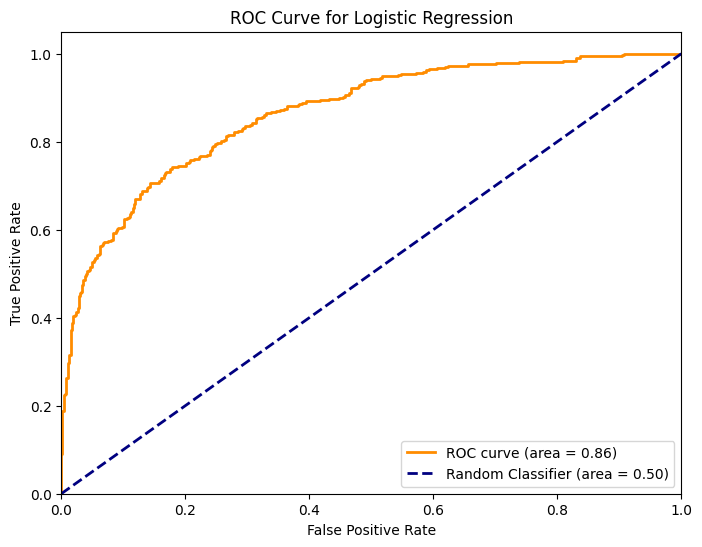

ROC curve saved to homeworks/HW05/figures/roc_curve_logreg.png


In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver='liblinear'))
])

param_grid = {
    'logreg__C': np.logspace(-4, 4, 20)
}

print("Pipeline and parameter grid created.")

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("GridSearchCV initialized. Starting training...")
grid_search.fit(X_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_logreg_model = grid_search.best_estimator_
y_pred_logreg = best_logreg_model.predict(X_test)
y_pred_proba_logreg = best_logreg_model.predict_proba(X_test)[:, 1]

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)

print(f"\nLogistic Regression Accuracy on Test Set: {accuracy_logreg:.4f}")
print(f"Logistic Regression ROC-AUC on Test Set: {roc_auc_logreg:.4f}")

# Plotting ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_logreg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc="lower right")

# Save the plot
roc_curve_path = os.path.join(figures_dir, 'roc_curve_logreg.png')
plt.savefig(roc_curve_path)
plt.show()
print(f"ROC curve saved to {roc_curve_path}")

## Сравнение моделей и отчет

### Subtask:
Сравнение результатов бейзлайн-модели и логистической регрессии по метрикам. Написание краткого отчета с объяснением различий в качестве моделей и выводами.


## Summary:

### Q&A
The task implicitly asked for a comparison of the Logistic Regression model's performance against the DummyClassifier baseline.

*   **How does the Logistic Regression model perform compared to the DummyClassifier baseline?**
    The Logistic Regression model significantly outperforms the DummyClassifier baseline.
    *   **Accuracy:** Logistic Regression achieved an accuracy of 0.7922, which is substantially higher than the DummyClassifier's accuracy of 0.5067.
    *   **ROC-AUC:** Logistic Regression achieved an ROC-AUC score of 0.8642, demonstrating a strong improvement over the DummyClassifier's ROC-AUC of 0.4893.

### Data Analysis Key Findings
*   The dataset `S05-hw-dataset.csv` contains 3000 entries and 17 columns with no missing values.
*   The target variable `default` shows a moderate class imbalance, with approximately 58.97% belonging to class 0 (no default) and 41.03% to class 1 (default).
*   The DummyClassifier (stratified strategy) established a baseline performance with an accuracy of 0.5067 and an ROC-AUC of 0.4893.
*   A Logistic Regression model, after standardization of features, was tuned using `GridSearchCV`. The optimal regularization parameter `C` was found to be approximately 0.0886, yielding a best cross-validation ROC-AUC of 0.8657.
*   On the test set, the tuned Logistic Regression model achieved an accuracy of 0.7922 and an ROC-AUC of 0.8642.
*   The ROC curve for the Logistic Regression model was generated and saved, visually confirming its strong performance compared to a random classifier.

### Insights or Next Steps
*   The Logistic Regression model shows promising performance for predicting credit default, significantly surpassing a random baseline.
*   Consider exploring more advanced classification algorithms (e.g., Gradient Boosting, Random Forest) or feature engineering techniques to potentially further improve model performance.
